## Testing data loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
from dataset import SuctionGraspingDataset, data_transform

In [6]:
dataset = SuctionGraspingDataset(
    data_path='../data',
    sample_list='../data/train-split.txt',
    transform=data_transform
)

# Use batch_size workers for multi‑threading as in the original code
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
)

for color_batch, depth_batch, label_batch in loader:
    print(color_batch.shape) # color_batch:  (B, 3, H, W)
    print(depth_batch.shape) # depth_batch:  (B, 3, H, W)
    print(label_batch.shape) # label_batch:  (B, H//8, W//8)
    break

torch.Size([4, 3, 480, 640])
torch.Size([4, 3, 480, 640])
torch.Size([4, 60, 80])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


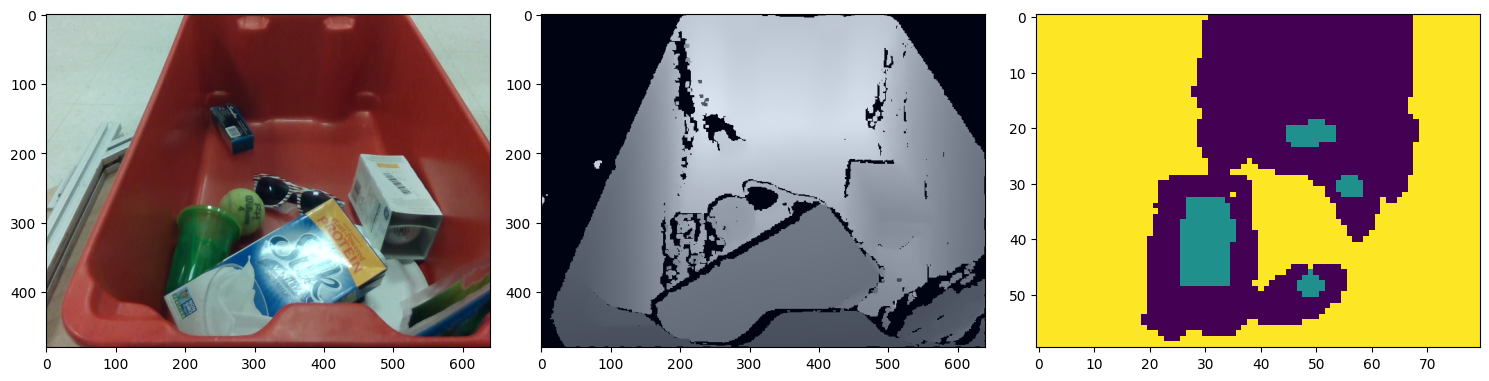

In [7]:
color_img_vis = torch.movedim(color_batch[0] * 0.229 + 0.485, 0, 2)
depth_img_vis = torch.movedim(depth_batch[0] * 0.229 + 0.485, 0, 2)
label_vis = label_batch[1] / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img_vis)
axes[1].imshow(depth_img_vis)
axes[2].imshow(label_vis)
plt.tight_layout()
plt.show()

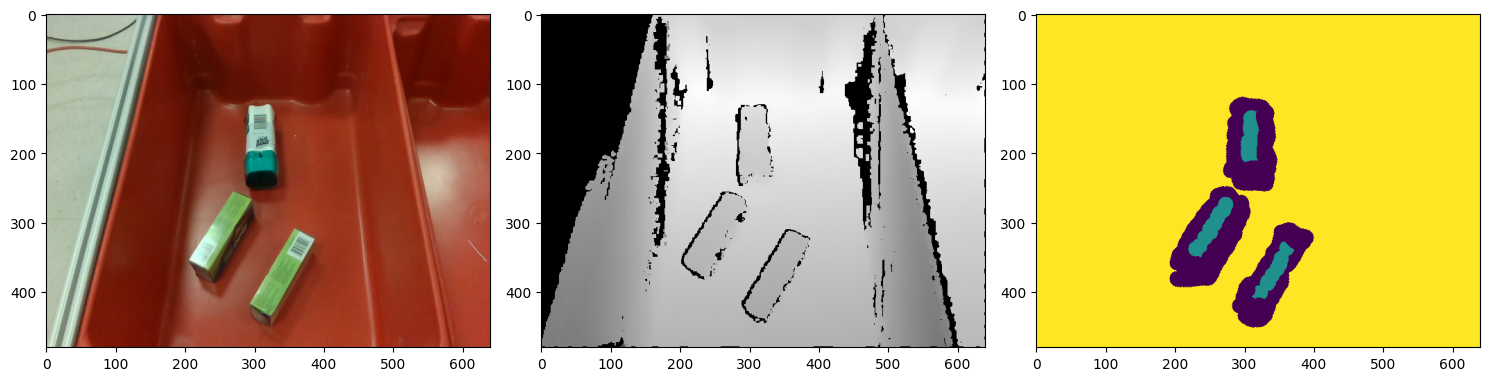

In [11]:
dataset = SuctionGraspingDataset(
    data_path='../data',
    sample_list='../data/train-split.txt',
    transform=None
)
color_img, depth_img, label_img = dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(color_img)
axes[1].imshow(depth_img, cmap="gray")
axes[2].imshow(label_img)
plt.tight_layout()
plt.show()

## Testing the model

In [12]:
from model import RGBDResNet101, masked_bce_loss

In [13]:
torch.cuda.empty_cache()

In [14]:
num_classes = 1
model = RGBDResNet101(num_classes=num_classes, pretrained=True).to(device)

In [15]:
torch.cuda.empty_cache()

In [16]:
output = model(color_batch.to(device), depth_batch.to(device))
print(f"Output shape: {output.shape}")
print(f"Labels shape: {label_batch.shape}")

loss = masked_bce_loss(output, label_batch.to(device))
print(f"Loss: {loss.cpu().item()}")

Output shape: torch.Size([4, 1, 60, 80])
Labels shape: torch.Size([4, 60, 80])
Loss: 0.7515644431114197


In [17]:
torch.cuda.empty_cache()

In [18]:
class ResNet2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = RGBDResNet101(num_classes=3)
    def forward(self, x):
        return self.model(x[0], x[1])

In [19]:
from torchinfo import summary

summary(ResNet2(), input_size=(2, 4, 3, 480, 640))

Layer (type:depth-idx)                             Output Shape              Param #
ResNet2                                            [4, 3, 60, 80]            --
├─RGBDResNet101: 1-1                               [4, 3, 60, 80]            --
│    └─Sequential: 2-1                             [4, 1024, 30, 40]         --
│    │    └─Conv2d: 3-1                            [4, 64, 240, 320]         9,408
│    │    └─BatchNorm2d: 3-2                       [4, 64, 240, 320]         (128)
│    │    └─ReLU: 3-3                              [4, 64, 240, 320]         --
│    │    └─MaxPool2d: 3-4                         [4, 64, 120, 160]         --
│    │    └─Sequential: 3-5                        [4, 256, 120, 160]        215,808
│    │    └─Sequential: 3-6                        [4, 512, 60, 80]          1,219,584
│    │    └─Sequential: 3-7                        [4, 1024, 30, 40]         26,090,496
│    └─Sequential: 2-2                             [4, 1024, 30, 40]         --
│    │   